<a href="https://colab.research.google.com/github/pg-2209/first-project/blob/main/prasanjeetproj3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("/content/Country-data.csv")

In [2]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

In [4]:
for col in df.columns[1:]:
  df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [6]:
X = df.drop('country', axis=1)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
k_values = range(2, 11)

In [9]:
import matplotlib.pyplot as plt



In [10]:
from sklearn.cluster import KMeans

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

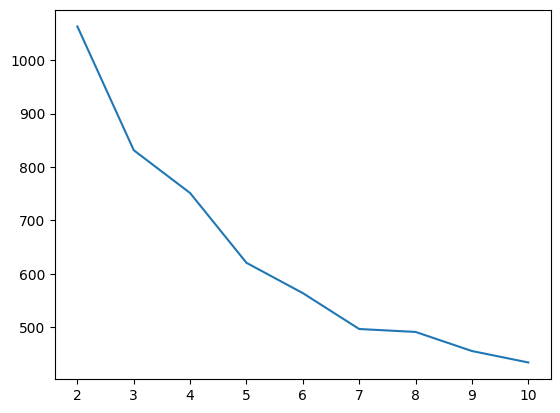

In [11]:
plt.plot(k_values, inertia)

In [12]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans.labels_)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.1962


In [13]:
from sklearn.cluster import KMeans

# Use best_k = 3 clusters
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_scaled)

# Get the inertia for this clustering
score = kmeans.inertia_

print(score)

831.5351582151586


In [14]:
print(score)

831.5351582151586


In [15]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

<Axes: >

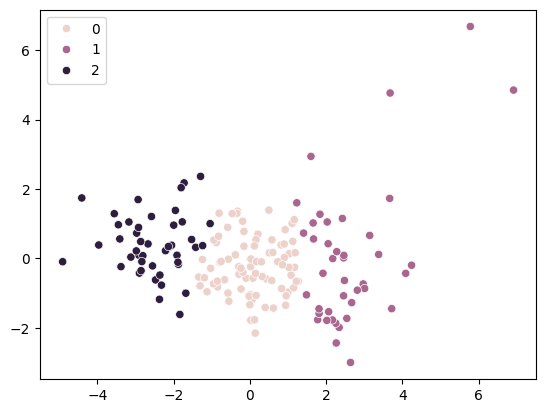

In [17]:
from sklearn.cluster import KMeans
import seaborn as sns

# Run KMeans on the PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans_pca.fit_predict(X_pca)

# Now plot with the labels
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels
)